# Sprint 4 — v9: multi-task auxiliary heads

**Project:** Q-INTERVAL-Lite+ · **Author:** Pasindu Pahasara (104348348)

## Why

v8 established that removing the source embedding does not remove the shortcut. On
ResNet-101 it lifted KAU-BCMD malignant recall from 0.1429 to 0.4286; on EfficientNetV2 the
same removal left it at **0.1429**, identical to the source-using ensemble. The model is
recovering provenance from the pixels — scanner response, preprocessing artefacts, greyscale
statistics — not from the metadata field.

So the question this notebook asks is different: **can I make the backbone encode lesion
morphology and tissue composition instead, by forcing it to predict them?**

Mammo-Bench ships three labels I have not been using as training signal:

| Auxiliary label | Coverage | Classes | Available on |
|---|---|---|---|
| Breast density | 13,519 (72.2%) | A / B / C / D | every source except CMMD |
| Abnormality type | 5,712 (30.5%) | normal / mass / calcification / both | CMMD, DMID |
| BI-RADS | 3,107 (16.6%) | 1–5 | DMID, INbreast, KAU-BCMD |

Predicting *mass vs calcification* cannot be solved from scanner greyscale statistics — it
requires reading lesion shape. Predicting *density* requires reading parenchymal pattern.
That is the mechanism by which this might work where deleting an input did not.

Density and BI-RADS were previously trained as **separate models**. Here they become heads on
one shared backbone, which is both cheaper and the point of the experiment.

## The trap in this data — read before running

The auxiliary labels are **almost perfectly confounded with source**:

| Source | density | BI-RADS | abnormality |
|---|---|---|---|
| cmmd (5,202) | 0% | 0% | **100%** |
| ddsm (10,400) | **100%** | 0% | 0% |
| dmid (510) | 99.6% | 96.3% | **100%** |
| inbreast (410) | 99.8% | **100%** | 0% |
| kau-bcmd (2,206) | **100%** | **100%** | 0% |

"Does this image carry an abnormality label?" is very nearly "is this CMMD?". A naive masked
multi-task loss therefore risks *teaching* provenance rather than removing it — the
abnormality head would receive gradient almost exclusively from CMMD images and could become
a CMMD feature detector.

Two mitigations are built in:

- `BALANCE_AUX_BY_SOURCE` averages each auxiliary loss over the sources present in the batch
  rather than over samples, so CMMD's 5,202 images cannot dominate the abnormality head.
- Worst-source malignant recall is logged every epoch. **If multi-task is entrenching the
  shortcut rather than breaking it, that number falls and the experiment has failed** — which
  is a real possible outcome, not a formality.

Density is the safest of the three: it covers four of five sources including KAU-BCMD, the
screening-like one. If only one auxiliary head survives, expect it to be that one.

## What to compare against

v8 EfficientNetV2 no-source, single model, no TTA, no threshold tuning — same split, same
backbone, same recipe. The only change here is the auxiliary heads.

| | v8 effnetv2 (no source) |
|---|---|
| accuracy | 0.7097 |
| macro F1 | 0.7152 |
| Benign F1 | 0.5851 |
| malignant recall | 0.7229 |
| worst-source malignant recall | 0.1429 |
| source spread | 0.7158 |

## Second experiment in the same notebook

`GROUP_DRO` switches the primary loss from average risk to **worst-group risk** over
source × class groups (Sagawa et al., 2020). That is the other candidate fix for the
shortcut and it optimises worst-source recall directly. Leave it off for run 1 so the
multi-task effect is attributable, then turn it on for run 2.

## 1. Configuration

In [ ]:
# ---------------- CONFIG ----------------
ARCH        = 'effnetv2'     # 'effnetv2' (v6 recipe, 384px) | 'resnet101' (512px)
USE_SOURCE  = False          # never an input again - v8 settled that

# ---- auxiliary heads (the experiment) ----
AUX_DENSITY = True;  W_DENSITY = 0.3     # 72.2% coverage, all sources but CMMD
AUX_ABNORM  = True;  W_ABNORM  = 0.3     # 30.5% coverage, CMMD + DMID
AUX_BIRADS  = False; W_BIRADS  = 0.2     # 16.6% coverage - most confounded, off by default

BALANCE_AUX_BY_SOURCE = True   # average aux loss over sources, not samples.
                               # Without this the abnormality head is trained
                               # almost entirely on CMMD.

# ---- experiment 2: worst-group optimisation ----
GROUP_DRO   = False          # True -> minimise worst (source x class) group loss
DRO_ETA     = 0.0001         # step size for the group-weight ascent.
                             # Tuned by simulation over 435 steps/epoch x 25 epochs:
                             #   0.01   -> q collapses onto ONE group inside 1 epoch
                             #   0.001  -> collapses by epoch 25
                             #   0.0001 -> worst group up-weighted ~3.4x, 13 of 15
                             #             groups still contributing at epoch 25
                             # Watch q_max in the epoch log; if it approaches 1.0 the
                             # model is training on a single group and eta is too high.

LOSS_TYPE   = 'ce'           # 'ce' | 'focal' | 'lmf'   (primary head)
USE_SAMPLER = True

SELECT_ON   = 'balanced'     # 'macro_f1' | 'worst_src_mal_recall' | 'balanced'
MIN_MAL_FOR_SELECTION = 20

EPOCHS   = 25
PATIENCE = 6
LR       = 1e-4
WD       = 1e-4

FOCAL_GAMMA = 2.0
LDAM_MAX_M, LDAM_S = 0.5, 30
LMF_ALPHA, LMF_BETA = 1.0, 1.0
DRW_START_EPOCH = None
# ----------------------------------------

_aux = ''.join([('d' if AUX_DENSITY else ''), ('a' if AUX_ABNORM else ''),
                ('b' if AUX_BIRADS else '')]) or 'none'
TAG = f"v9_{ARCH}_mt-{_aux}{'_dro' if GROUP_DRO else ''}_{LOSS_TYPE}"
print('Experiment:', TAG)
print('Auxiliary heads:', {'density': AUX_DENSITY, 'abnormality': AUX_ABNORM, 'birads': AUX_BIRADS})
print('Group DRO:', GROUP_DRO, '| selection:', SELECT_ON)

Experiment: v9_effnetv2_mt-da_ce
Auxiliary heads: {'density': True, 'abnormality': True, 'birads': False}
Group DRO: False | selection: balanced


## 2. Setup

In [ ]:
!pip install -q albumentations scikit-learn tqdm matplotlib seaborn

import os, time, json, random
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.models import (resnet101, ResNet101_Weights,
                                efficientnet_v2_s, EfficientNet_V2_S_Weights)
import cv2, albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (accuracy_score, f1_score, recall_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix, classification_report)
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
CLASS_NAMES = ['Normal', 'Benign', 'Malignant']
MAL = 2
IGNORE = -100          # torch's cross_entropy ignore_index - how missing aux labels are masked
print('Device:', device)

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT  = '/content/drive/MyDrive/momobench-dataset'
EXTRACT_DIR = '/content/dataset_original'
CHECKPT_DIR = os.path.join(DRIVE_ROOT, f'checkpoints_{TAG}')
SPLIT_PATH  = os.path.join(DRIVE_ROOT, 'sprint4_audit', 'frozen_split.json')
os.makedirs(CHECKPT_DIR, exist_ok=True)

if not os.path.isdir(os.path.join(EXTRACT_DIR, 'dataset')):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    os.system(f'unzip -q "{DRIVE_ROOT}/dataset.zip" -d "{EXTRACT_DIR}"')
    print('extracted')
else:
    print('already extracted')

IMG_ROOT  = os.path.join(EXTRACT_DIR, 'dataset')
META_PATH = os.path.join(IMG_ROOT, 'metadata.csv')
print('frozen split available:', os.path.exists(SPLIT_PATH))

Mounted at /content/drive
extracted
frozen split available: True


## 3. Data — same frozen split, plus three auxiliary label columns

Test set is byte-identical to every other Sprint 4 run. Missing auxiliary labels are encoded
as `IGNORE = -100` so `F.cross_entropy` drops them without any masking arithmetic on my side.

In [ ]:
df = pd.read_csv(META_PATH)
df['classification'] = df['classification'].replace({'Suspicious Malignant': 'Malignant'})
df = df[df['source_dataset'] != 'cdd-cesm'].reset_index(drop=True)
df['image_path'] = df['preprocessed_image_path'].apply(lambda r: os.path.join(IMG_ROOT, r))
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)
df['label'] = df['classification'].map({c: i for i, c in enumerate(CLASS_NAMES)})

# ---- clinical covariates available at inference ----
def age_bucket(a):
    if pd.isna(a): return 7
    for i, hi in enumerate([30, 40, 50, 60, 70, 80]):
        if a < hi: return i
    return 6
df['age_idx']  = df['subject_age'].apply(age_bucket); N_AGE = 8
df['view_idx'] = df['view'].map({'CC': 0, 'MLO': 1}).fillna(2).astype(int); N_VIEW = 3
df['lat_idx']  = df['laterality'].map({'L': 0, 'R': 1}).astype(int); N_LAT = 2
SOURCE_NAMES = sorted(df['source_dataset'].unique()); N_SRC = len(SOURCE_NAMES)
df['src_idx'] = df['source_dataset'].map({s: i for i, s in enumerate(SOURCE_NAMES)})

# ---- auxiliary targets, IGNORE where absent ----
DENSITY_NAMES = ['A', 'B', 'C', 'D']; N_DENSITY = 4
df['den_idx'] = df['density'].map({d: i for i, d in enumerate(DENSITY_NAMES)}).fillna(IGNORE).astype(int)

# BI-RADS 1-5 only. 0 = incomplete assessment, 6 = biopsy-proven - both excluded
# for the same reason they were excluded from the standalone BI-RADS model in Sprint 2.
N_BIRADS = 5
df['bir_idx'] = df['BIRADS'].apply(lambda b: int(b) - 1 if pd.notna(b) and 1 <= b <= 5 else IGNORE).astype(int)

# 'others' (10 rows) dropped rather than given a class of its own
ABNORM_NAMES = ['normal', 'mass', 'calcification', 'both']; N_ABNORM = 4
df['abn_idx'] = df['abnormality'].map({a: i for i, a in enumerate(ABNORM_NAMES)}).fillna(IGNORE).astype(int)

if os.path.exists(SPLIT_PATH):
    sp = json.load(open(SPLIT_PATH))
    train_ids = set(sp['train']) | set(sp['validation'])
    sel_ids   = set(sp['selection'])
    test_ids  = set(sp['test'])
    print('Using frozen split from the audit.')
else:
    raise FileNotFoundError('Run Sprint4_Step1_Audit.ipynb first to create frozen_split.json')

train_df = df[df['source_subjectID'].isin(train_ids)].reset_index(drop=True)
sel_df   = df[df['source_subjectID'].isin(sel_ids)].reset_index(drop=True)
test_df  = df[df['source_subjectID'].isin(test_ids)].reset_index(drop=True)

CLS_NUM_LIST = train_df['label'].value_counts().sort_index().to_numpy()
print(f'train     {len(train_df):5d} images  ({train_df.source_subjectID.nunique()} patients)')
print(f'selection {len(sel_df):5d} images  ({sel_df.source_subjectID.nunique()} patients)')
print(f'test      {len(test_df):5d} images  ({test_df.source_subjectID.nunique()} patients)  FROZEN')
print(f'train class counts: {dict(zip(CLASS_NAMES, CLS_NUM_LIST))}')

print('\nAUXILIARY LABEL COVERAGE IN TRAIN')
for name, col, n_cls in [('density', 'den_idx', N_DENSITY),
                         ('abnormality', 'abn_idx', N_ABNORM),
                         ('birads', 'bir_idx', N_BIRADS)]:
    have = (train_df[col] != IGNORE)
    by_src = train_df[have].groupby('source_dataset').size().to_dict()
    print(f'  {name:12s} {have.sum():6d} / {len(train_df)}  ({100*have.mean():5.1f}%)   {by_src}')

Using frozen split from the audit.
train     13917 images  (4122 patients)
selection  1990 images  (581 patients)
test       2821 images  (831 patients)  FROZEN
train class counts: {'Normal': np.int64(3642), 'Benign': np.int64(4276), 'Malignant': np.int64(5999)}

AUXILIARY LABEL COVERAGE IN TRAIN
  density       10064 / 13917  ( 72.3%)   {'ddsm': 7752, 'dmid': 379, 'inbreast': 305, 'kau-bcmd': 1628}
  abnormality    4219 / 13917  ( 30.3%)   {'cmmd': 3846, 'dmid': 373}
  birads         2293 / 13917  ( 16.5%)   {'dmid': 364, 'inbreast': 301, 'kau-bcmd': 1628}


### 3a. Confounding check — how much source does the missingness pattern carry?

This is the number that decides whether the mitigation is needed or merely tidy. If knowing
*which auxiliary labels are present* predicts source almost perfectly, then an unbalanced
auxiliary loss is a provenance signal with extra steps.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pattern = np.stack([(train_df['den_idx'] != IGNORE).to_numpy().astype(int),
                    (train_df['abn_idx'] != IGNORE).to_numpy().astype(int),
                    (train_df['bir_idx'] != IGNORE).to_numpy().astype(int)], 1)
acc = cross_val_score(LogisticRegression(max_iter=1000), pattern,
                      train_df['src_idx'].to_numpy(), cv=3, scoring='accuracy').mean()
print(f'Predicting SOURCE from the label-presence pattern alone: {acc:.4f} accuracy')
print(f'(chance = {1.0/N_SRC:.4f}, majority class = {train_df["src_idx"].value_counts(normalize=True).max():.4f})')
print()
print(pd.crosstab(train_df['source_dataset'],
                  [pattern[:, 0], pattern[:, 1], pattern[:, 2]]).to_string())
print('\nIf this is near-perfect, BALANCE_AUX_BY_SOURCE is doing real work, not cosmetics.')

Predicting SOURCE from the label-presence pattern alone: 0.9770 accuracy
(chance = 0.2000, majority class = 0.5573)

col_0           0                 1               
col_1           0        1        0         1     
col_2           0  1     0  1     0     1   0    1
source_dataset                                    
cmmd            0  0  3846  0     0     0   0    0
ddsm            4  0     0  0  7752     0   0    0
dmid            0  0     0  2     0     8  17  354
inbreast        0  1     0  0     5   300   0    0
kau-bcmd        0  0     0  0     0  1628   0    0

If this is near-perfect, BALANCE_AUX_BY_SOURCE is doing real work, not cosmetics.


## 4. Augmentation and loaders

In [ ]:
IMG_SIZE   = 512 if ARCH == 'resnet101' else 384
BATCH_SIZE = 16  if ARCH == 'resnet101' else 32
NORM_MEAN, NORM_STD = [0.485,0.456,0.406], [0.229,0.224,0.225]

train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.12, rotate_limit=18,
                       border_mode=cv2.BORDER_CONSTANT, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.18, contrast_limit=0.18, p=0.5),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD), ToTensorV2()])
eval_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
                     A.Normalize(mean=NORM_MEAN, std=NORM_STD), ToTensorV2()])


class MammoMTDS(Dataset):
    '''Source index is returned for grouping and reporting only.
    It is never fed to the model while USE_SOURCE is False.'''
    def __init__(self, d, transform):
        self.df = d.reset_index(drop=True); self.tf = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.cvtColor(cv2.imread(r['image_path']), cv2.COLOR_BGR2RGB)
        return (self.tf(image=img)['image'],
                int(r['age_idx']), int(r['view_idx']), int(r['lat_idx']), int(r['src_idx']),
                int(r['label']), int(r['den_idx']), int(r['abn_idx']), int(r['bir_idx']))


train_ds = MammoMTDS(train_df, train_tf)
sel_ds   = MammoMTDS(sel_df,   eval_tf)
test_ds  = MammoMTDS(test_df,  eval_tf)

if USE_SAMPLER:
    w  = 1.0 / CLS_NUM_LIST
    sw = train_df['label'].map(lambda c: w[c]).to_numpy()
    sampler = WeightedRandomSampler(torch.tensor(sw, dtype=torch.double), len(sw), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=2, pin_memory=True)
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
sel_loader  = DataLoader(sel_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'{ARCH} @ {IMG_SIZE}px, batch {BATCH_SIZE}')

effnetv2 @ 384px, batch 32


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 5. Model — one backbone, four heads

The auxiliary heads are deliberately thin (a single linear layer on the pooled feature). The
point is to shape the **backbone**, not to build good density or BI-RADS classifiers — those
already exist as standalone models. A heavy auxiliary head would learn the task in the head
and leave the backbone unchanged, which is the failure mode to avoid.

Auxiliary heads read the pooled image feature only, not the metadata embeddings: density
predicted from an age embedding would be cheating.

In [ ]:
N_META = 4 if USE_SOURCE else 3

class CBAM(nn.Module):
    def __init__(self, c, r=16, k=7):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1); self.mx = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(nn.Conv2d(c, c//r, 1, bias=False), nn.ReLU(inplace=True),
                                 nn.Conv2d(c//r, c, 1, bias=False))
        self.sp = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
    def forward(self, x):
        x = x * torch.sigmoid(self.mlp(self.avg(x)) + self.mlp(self.mx(x)))
        return x * torch.sigmoid(self.sp(torch.cat([x.mean(1, keepdim=True),
                                                    x.amax(1, keepdim=True)], 1)))


class MultiTaskNet(nn.Module):
    def __init__(self, arch='effnetv2', emb=16, dr=0.3):
        super().__init__()
        self.arch = arch
        if arch == 'resnet101':
            self.backbone = resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
            self.backbone.fc = nn.Identity(); feat_dim = 2048; self.cbam = None
        else:
            self.features = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1).features
            self.cbam = CBAM(1280); self.avgpool = nn.AdaptiveAvgPool2d(1); feat_dim = 1280
        self.feat_dim = feat_dim

        self.age_emb  = nn.Embedding(N_AGE,  emb)
        self.view_emb = nn.Embedding(N_VIEW, emb)
        self.lat_emb  = nn.Embedding(N_LAT,  emb)
        self.src_emb  = nn.Embedding(N_SRC,  emb) if USE_SOURCE else None

        # primary head sees image + clinical covariates
        self.classifier = nn.Sequential(
            nn.Dropout(dr), nn.Linear(feat_dim + N_META*emb, 256),
            nn.ReLU(inplace=True), nn.Dropout(dr), nn.Linear(256, 3))

        # auxiliary heads see the image feature only
        self.head_den = nn.Linear(feat_dim, N_DENSITY) if AUX_DENSITY else None
        self.head_abn = nn.Linear(feat_dim, N_ABNORM)  if AUX_ABNORM  else None
        self.head_bir = nn.Linear(feat_dim, N_BIRADS)  if AUX_BIRADS  else None

    def trunk(self, x):
        if self.arch == 'resnet101':
            return self.backbone(x)
        return self.avgpool(self.cbam(self.features(x))).flatten(1)

    def meta(self, a, v, l, s):
        parts = [self.age_emb(a), self.view_emb(v), self.lat_emb(l)]
        if self.src_emb is not None: parts.append(self.src_emb(s))
        return torch.cat(parts, 1)

    def forward(self, x, a, v, l, s):
        f = self.trunk(x)
        out = {'cls': self.classifier(torch.cat([f, self.meta(a, v, l, s)], 1))}
        if self.head_den is not None: out['den'] = self.head_den(f)
        if self.head_abn is not None: out['abn'] = self.head_abn(f)
        if self.head_bir is not None: out['bir'] = self.head_bir(f)
        return out


model = MultiTaskNet(ARCH).to(device)
n_heads = 1 + sum(h is not None for h in [model.head_den, model.head_abn, model.head_bir])
print(f'{ARCH}: {sum(p.numel() for p in model.parameters())/1e6:.2f}M params, {n_heads} heads')
print('source embedding present:', model.src_emb is not None)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:01<00:00, 45.8MB/s]


effnetv2: 20.73M params, 3 heads
source embedding present: False


## 6. Losses

Three pieces:

1. **Primary loss** — unchanged from v8 (CE / Focal / LMF), so the comparison is clean.
2. **Auxiliary loss** — masked cross-entropy, optionally averaged over sources rather than
   samples so CMMD cannot dominate the abnormality head.
3. **Group DRO** — off by default. When on, the primary loss becomes the worst-group loss
   over source × class, with group weights updated by exponentiated gradient ascent.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__(); self.gamma = gamma; self.weight = weight
    def forward(self, x, t, reduction='mean'):
        w = self.weight.to(x.device) if self.weight is not None else None
        ce = F.cross_entropy(x, t, weight=w, reduction='none')
        l = (1 - torch.exp(-ce))**self.gamma * ce
        return l if reduction == 'none' else l.mean()

class LDAMLoss(nn.Module):
    def __init__(self, cls_num_list, max_m=0.5, s=30, weight=None):
        super().__init__()
        m = 1.0/np.sqrt(np.sqrt(np.asarray(cls_num_list, float))); m = m*(max_m/m.max())
        self.register_buffer('m_list', torch.tensor(m, dtype=torch.float32))
        self.s = s; self.weight = weight
    def forward(self, x, t, reduction='mean'):
        idx = torch.zeros_like(x, dtype=torch.bool); idx.scatter_(1, t.view(-1,1), True)
        out = torch.where(idx, x - self.m_list.to(x.device)[t].view(-1,1), x)
        w = self.weight.to(x.device) if self.weight is not None else None
        return F.cross_entropy(self.s*out, t, weight=w, reduction=reduction)

class LMFLoss(nn.Module):
    def __init__(self, cls_num_list, a=1.0, b=1.0, gamma=2.0, max_m=0.5, s=30, weight=None):
        super().__init__()
        self.f = FocalLoss(gamma, weight); self.l = LDAMLoss(cls_num_list, max_m, s, weight)
        self.a, self.b = a, b
    def forward(self, x, t, reduction='mean'):
        return self.a*self.f(x, t, reduction) + self.b*self.l(x, t, reduction)

class CELoss(nn.Module):
    def __init__(self, weight=None):
        super().__init__(); self.weight = weight
    def forward(self, x, t, reduction='mean'):
        w = self.weight.to(x.device) if self.weight is not None else None
        return F.cross_entropy(x, t, weight=w, reduction=reduction)

def build_criterion(kind, cls, weight=None):
    if kind == 'ce':    return CELoss(weight)
    if kind == 'focal': return FocalLoss(FOCAL_GAMMA, weight)
    if kind == 'lmf':   return LMFLoss(cls, LMF_ALPHA, LMF_BETA, FOCAL_GAMMA, LDAM_MAX_M, LDAM_S, weight)
    raise ValueError(kind)

def cb_weights(cls, beta=0.9999):
    eff = 1.0 - np.power(beta, cls); w = (1.0-beta)/eff
    return torch.tensor(w/w.sum()*len(cls), dtype=torch.float32)


def masked_aux_ce(logits, target, src, balance=True):
    '''Cross-entropy over rows whose auxiliary label exists.

    balance=True averages per source present in the batch instead of per sample, so a
    source contributing 30 labelled rows counts the same as one contributing 2.
    Returns a real zero (attached to the graph) when nothing in the batch is labelled.
    '''
    valid = target != IGNORE
    if valid.sum() == 0:
        return logits.sum() * 0.0
    l = F.cross_entropy(logits[valid], target[valid], reduction='none')
    if not balance:
        return l.mean()
    s = src[valid]
    tot = logits.sum() * 0.0; n = 0
    for si in torch.unique(s):
        tot = tot + l[s == si].mean(); n += 1
    return tot / max(n, 1)


class GroupDRO:
    '''Sagawa et al. 2020. Group weights q updated by exponentiated gradient ascent on
    per-group mean loss; the objective becomes sum_g q_g * loss_g, which concentrates on
    the worst-performing group. Groups here are source x class.'''
    def __init__(self, n_groups, eta=0.01):
        self.q = torch.ones(n_groups, device=device) / n_groups
        self.eta = eta; self.n = n_groups
    def stats(self):
        i = int(self.q.argmax())
        return float(self.q.max()), i

    def __call__(self, per_sample_loss, group_idx):
        g_sum = torch.zeros(self.n, device=per_sample_loss.device, dtype=per_sample_loss.dtype)
        g_cnt = torch.zeros(self.n, device=per_sample_loss.device, dtype=per_sample_loss.dtype)
        g_sum.index_add_(0, group_idx, per_sample_loss)
        g_cnt.index_add_(0, group_idx, torch.ones_like(per_sample_loss))
        present = g_cnt > 0
        g_mean = torch.zeros_like(g_sum)
        g_mean[present] = g_sum[present] / g_cnt[present]
        with torch.no_grad():
            self.q[present] *= torch.exp(self.eta * g_mean[present].detach().float())
            self.q /= self.q.sum()
        return (self.q.to(g_mean.dtype) * g_mean).sum()


criterion = build_criterion(LOSS_TYPE, CLS_NUM_LIST)
dro = GroupDRO(N_SRC * 3, DRO_ETA) if GROUP_DRO else None
AUX_SPEC = [(k, w) for k, w, on in
            [('den', W_DENSITY, AUX_DENSITY), ('abn', W_ABNORM, AUX_ABNORM), ('bir', W_BIRADS, AUX_BIRADS)] if on]
print('primary loss:', LOSS_TYPE, '| aux heads and weights:', AUX_SPEC, '| DRO:', GROUP_DRO)

primary loss: ce | aux heads and weights: [('den', 0.3), ('abn', 0.3)] | DRO: False


## 7. Training

Per-epoch reporting is identical to v8 so the runs can be read side by side, with one
addition: each auxiliary head's own loss is logged, so a head that is learning nothing is
visible rather than silently consuming capacity.

In [ ]:
AUX_TARGET_POS = {'den': 6, 'abn': 7, 'bir': 8}   # index into the batch tuple

def train_one_epoch(m, loader, opt, crit, scaler):
    m.train()
    tot, corr, n = 0.0, 0, 0
    aux_running = {k: 0.0 for k, _ in AUX_SPEC}
    for batch in tqdm(loader, leave=False, desc='train'):
        x, a, v, l, s, y = [t.to(device, non_blocking=True) for t in batch[:6]]
        aux_t = {k: batch[AUX_TARGET_POS[k]].to(device) for k, _ in AUX_SPEC}
        opt.zero_grad()
        with torch.amp.autocast(device_type='cuda'):
            out = m(x, a, v, l, s)
            if GROUP_DRO:
                per_sample = crit(out['cls'], y, reduction='none')
                loss = dro(per_sample, s * 3 + y)
            else:
                loss = crit(out['cls'], y)
            for k, wgt in AUX_SPEC:
                la = masked_aux_ce(out[k], aux_t[k], s, BALANCE_AUX_BY_SOURCE)
                loss = loss + wgt * la
                aux_running[k] += float(la.detach()) * x.size(0)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tot += loss.item()*x.size(0); corr += (out['cls'].argmax(1) == y).sum().item(); n += x.size(0)
    return tot/n, corr/n, {k: v/n for k, v in aux_running.items()}


@torch.no_grad()
def evaluate(m, loader, crit, src_arr=None):
    m.eval(); tot, n = 0.0, 0; L, Y = [], []
    for batch in tqdm(loader, leave=False, desc='eval'):
        x, a, v, l, s, y = [t.to(device, non_blocking=True) for t in batch[:6]]
        with torch.amp.autocast(device_type='cuda'):
            out = m(x, a, v, l, s); loss = crit(out['cls'], y)
        tot += loss.item()*x.size(0); n += x.size(0)
        L.append(out['cls'].float().cpu()); Y.append(y.cpu())
    L, Y = torch.cat(L), torch.cat(Y)
    pred, yt = L.argmax(1).numpy(), Y.numpy()
    probs = F.softmax(L, 1).numpy()
    f1s = f1_score(yt, pred, average=None, labels=[0,1,2], zero_division=0)
    out = {'loss': tot/n,
           'accuracy': accuracy_score(yt, pred),
           'macro_f1': f1_score(yt, pred, average='macro', zero_division=0),
           'benign_f1': f1s[1],
           'mal_recall': recall_score(yt, pred, labels=[MAL], average='macro', zero_division=0),
           'mcc': matthews_corrcoef(yt, pred),
           'macro_auc': roc_auc_score(yt, probs, multi_class='ovr', average='macro')}
    if src_arr is not None:
        per_all, per_stable = {}, {}
        for si, sname in enumerate(SOURCE_NAMES):
            mk = src_arr == si
            if mk.sum() < 20: continue
            r = recall_score(yt[mk], pred[mk], labels=[MAL], average='macro', zero_division=0)
            per_all[sname] = r
            if (yt[mk] == MAL).sum() >= MIN_MAL_FOR_SELECTION:
                per_stable[sname] = r
        out['per_source_mal_recall'] = per_all
        out['stable_sources']        = sorted(per_stable)
        out['worst_src_mal_recall']  = min(per_stable.values()) if per_stable else 0.0
        out['worst_src_name']        = min(per_stable, key=per_stable.get) if per_stable else '-'
    return out, L, Y, probs


sel_src  = sel_df['src_idx'].to_numpy()
test_src = test_df['src_idx'].to_numpy()
print('Sources eligible to drive checkpoint selection (>= '
      f'{MIN_MAL_FOR_SELECTION} malignant in selection set):')
for si, s in enumerate(SOURCE_NAMES):
    mk = sel_df['src_idx'].to_numpy() == si
    nm = int((sel_df['label'].to_numpy()[mk] == MAL).sum())
    print(f'  {s:10s} n={int(mk.sum()):4d}  malignant={nm:3d}   '
          f'{"drives selection" if nm >= MIN_MAL_FOR_SELECTION else "reported only"}')

Sources eligible to drive checkpoint selection (>= 20 malignant in selection set):
  cmmd       n= 530  malignant=414   drives selection
  ddsm       n=1116  malignant=384   drives selection
  dmid       n=  53  malignant= 15   reported only
  inbreast   n=  43  malignant= 10   reported only
  kau-bcmd   n= 248  malignant= 10   reported only


In [ ]:
scaler = torch.amp.GradScaler('cuda')
opt   = AdamW(model.parameters(), lr=LR, weight_decay=WD)
sched = CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

CKPT = os.path.join(CHECKPT_DIR, f'best_{TAG}.pth')
best, patience_ctr, history = -1.0, 0, []

def score_of(m):
    if SELECT_ON == 'macro_f1':             return m['macro_f1']
    if SELECT_ON == 'worst_src_mal_recall': return m['worst_src_mal_recall']
    if SELECT_ON == 'balanced':             return 0.5*m['macro_f1'] + 0.5*m['worst_src_mal_recall']
    raise ValueError(SELECT_ON)

for ep in range(1, EPOCHS+1):
    if DRW_START_EPOCH is not None and ep == DRW_START_EPOCH:
        criterion = build_criterion(LOSS_TYPE, CLS_NUM_LIST, cb_weights(CLS_NUM_LIST))
        print(f'--- epoch {ep}: DRW enabled ---')
    t0 = time.time()
    tr_loss, tr_acc, aux_loss = train_one_epoch(model, train_loader, opt, criterion, scaler)
    sm, *_ = evaluate(model, sel_loader, criterion, sel_src)
    sched.step()

    ps  = '  '.join(f'{k[:4]}={v:.2f}' for k, v in sm['per_source_mal_recall'].items())
    axs = '  '.join(f'{k}={v:.3f}' for k, v in aux_loss.items()) or 'none'
    dro_note = ''
    if GROUP_DRO:
        qmax, gi = dro.stats()
        dro_note = (f'  DRO q_max={qmax:.3f} on {SOURCE_NAMES[gi//3]} x {CLASS_NAMES[gi%3]}'
                    f'{"   <-- SATURATED, lower DRO_ETA" if qmax > 0.6 else ""}')
    print(f'ep {ep:>2}: tr_acc={tr_acc:.4f} | sel_acc={sm["accuracy"]:.4f} '
          f'f1={sm["macro_f1"]:.4f} ben={sm["benign_f1"]:.4f} mal={sm["mal_recall"]:.4f} '
          f'| WORST-SRC mal_rec={sm["worst_src_mal_recall"]:.3f} ({sm["worst_src_name"]}) '
          f'({time.time()-t0:.0f}s)')
    print(f'        per-source mal recall:  {ps}')
    print(f'        aux losses:             {axs}')
    if dro_note: print(f'       {dro_note}')
    history.append({'epoch': ep, 'tr_acc': tr_acc,
                    **{k: v for k, v in sm.items() if k != 'per_source_mal_recall'},
                    **{f'aux_{k}': v for k, v in aux_loss.items()}})

    sc = score_of(sm)
    if sc > best:
        best = sc
        torch.save({'model_state_dict': model.state_dict(), 'sel_metrics': sm, 'epoch': ep}, CKPT)
        print(f'        saved best ({SELECT_ON}={best:.4f})')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'        early stop after {PATIENCE} epochs'); break

train:   0%|          | 0/435 [00:00<?, ?it/s]

eval:   0%|          | 0/63 [00:00<?, ?it/s]

ep  1: tr_acc=0.6254 | sel_acc=0.6643 f1=0.6615 ben=0.5587 mal=0.6399 | WORST-SRC mal_rec=0.307 (ddsm) (415s)
        per-source mal recall:  cmmd=1.00  ddsm=0.31  dmid=0.13  inbr=0.00  kau-=0.00
        aux losses:             den=1.097  abn=1.004
        saved best (balanced=0.4844)


train:   0%|          | 0/435 [00:00<?, ?it/s]

eval:   0%|          | 0/63 [00:00<?, ?it/s]

...

eval:   0%|          | 0/63 [00:00<?, ?it/s]

ep 15: tr_acc=0.8915 | sel_acc=0.6970 f1=0.6978 ben=0.5935 mal=0.6663 | WORST-SRC mal_rec=0.508 (ddsm) (374s)
        per-source mal recall:  cmmd=0.83  ddsm=0.51  dmid=0.67  inbr=0.60  kau-=0.00
        aux losses:             den=0.415  abn=0.504


train:   0%|          | 0/435 [00:00<?, ?it/s]

eval:   0%|          | 0/63 [00:00<?, ?it/s]

ep 16: tr_acc=0.8990 | sel_acc=0.6774 f1=0.6797 ben=0.5447 mal=0.6615 | WORST-SRC mal_rec=0.536 (ddsm) (375s)
        per-source mal recall:  cmmd=0.79  ddsm=0.54  dmid=0.87  inbr=0.60  kau-=0.10
        aux losses:             den=0.365  abn=0.439
        early stop after 6 epochs


## 8. Curves — the worst-source line is the one that decides this experiment

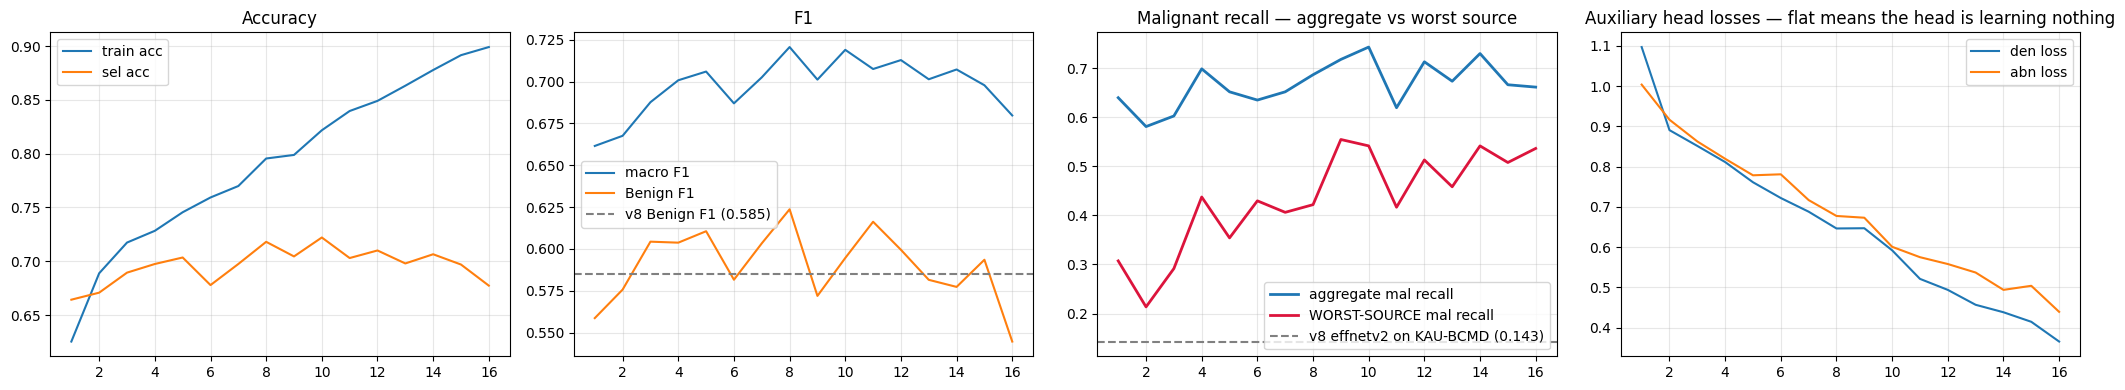

,epoch,tr_acc,loss,accuracy,macro_f1,benign_f1,mal_recall,mcc,macro_auc,stable_sources,worst_src_mal_recall,worst_src_name,aux_den,aux_abn
4,5,0.7456,0.6469,0.7035,0.7059,0.6106,0.6519,0.5547,0.8738,"[cmmd, ddsm]",0.3542,ddsm,0.7612,0.7785
5,6,0.7593,0.6613,0.6779,0.6870,0.5816,0.6351,0.5155,0.8665,"[cmmd, ddsm]",0.4297,ddsm,0.7220,0.7810
6,7,0.7699,0.6517,0.6975,0.7025,0.6033,0.6519,0.5433,0.8746,"[cmmd, ddsm]",0.4062,ddsm,0.6881,0.7170
7,8,0.7955,0.6713,0.7181,0.7206,0.6237,0.6867,0.5734,0.8764,"[cmmd, ddsm]",0.4219,ddsm,0.6464,0.6775
8,9,0.7988,0.6703,0.7045,0.7011,0.5719,0.7179,0.5507,0.8696,"[cmmd, ddsm]",0.5547,ddsm,0.6470,0.6731
9,10,0.8217,0.7486,0.7221,0.7189,0.5946,0.7431,0.5769,0.8717,"[cmmd, ddsm]",0.5417,ddsm,0.5921,0.6009
10,11,0.8396,0.7521,0.7030,0.7075,0.6162,0.6194,0.5564,0.8724,"[cmmd, ddsm]",0.4167,ddsm,0.5212,0.5751
11,12,0.8490,0.7938,0.7101,0.7128,0.5995,0.7131,0.5572,0.8690,"[cmmd, ddsm]",0.5130,ddsm,0.4938,0.5581
12,13,0.8631,0.8684,0.6980,0.7013,0.5815,0.6735,0.5416,0.8589,"[cmmd, ddsm]",0.4583,ddsm,0.4568,0.5369
13,14,0.8777,0.9334,0.7065,0.7072,0.5773,0.7299,0.5512,0.8573,"[cmmd, ddsm]",0.5417,ddsm,0.4383,0.4939


In [ ]:
h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 4, figsize=(21, 4))
ax[0].plot(h.epoch, h.tr_acc, label='train acc'); ax[0].plot(h.epoch, h.accuracy, label='sel acc')
ax[0].set_title('Accuracy'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(h.epoch, h.macro_f1, label='macro F1'); ax[1].plot(h.epoch, h.benign_f1, label='Benign F1')
ax[1].axhline(0.5851, ls='--', c='grey', label='v8 Benign F1 (0.585)')
ax[1].set_title('F1'); ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].plot(h.epoch, h.mal_recall, label='aggregate mal recall', lw=2)
ax[2].plot(h.epoch, h.worst_src_mal_recall, label='WORST-SOURCE mal recall', lw=2, color='crimson')
ax[2].axhline(0.1429, ls='--', c='grey', label='v8 effnetv2 on KAU-BCMD (0.143)')
ax[2].set_title('Malignant recall — aggregate vs worst source'); ax[2].legend(); ax[2].grid(alpha=.3)
if AUX_SPEC:
    for k, _ in AUX_SPEC:
        ax[3].plot(h.epoch, h[f'aux_{k}'], label=f'{k} loss')
    ax[3].set_title('Auxiliary head losses — flat means the head is learning nothing')
    ax[3].legend()
else:
    ax[3].text(0.5, 0.5, 'no auxiliary heads\nin this run', ha='center', va='center',
               transform=ax[3].transAxes, color='grey')
    ax[3].set_title('Auxiliary head losses')
ax[3].grid(alpha=.3)
plt.tight_layout(); plt.show()
display(h.round(4).tail(12))

## 9. Test evaluation with per-source breakdown

Loaded epoch 10


eval:   0%|          | 0/89 [00:00<?, ?it/s]


AGGREGATE TEST METRICS
  accuracy     = 0.7168
  macro_f1     = 0.7124
  benign_f1    = 0.5754
  mal_recall   = 0.7452
  mcc          = 0.5652
  macro_auc    = 0.8760

PER-SOURCE BREAKDOWN


,n,pct_malignant,accuracy,macro_f1,benign_f1,mal_recall
source,,,,,,
cmmd,826,0.797,0.7881,0.6115,0.3494,0.9179
ddsm,1528,0.359,0.6283,0.6333,0.5917,0.5639
dmid,76,0.276,0.6579,0.6295,0.4444,0.7143
inbreast,61,0.246,0.7869,0.7108,0.8571,0.4667
kau-bcmd,330,0.042,0.9485,0.6492,0.8298,0.0714


Worst-source malignant recall: 0.0714 (kau-bcmd)
Spread across sources:         0.8465


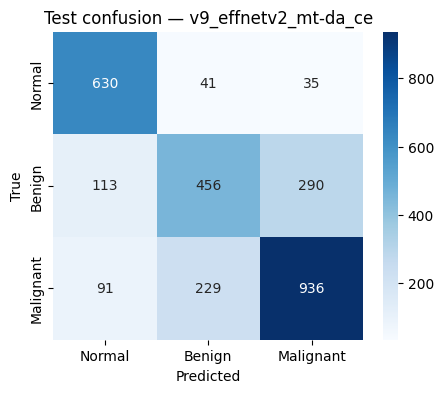

              precision    recall  f1-score   support

      Normal     0.7554    0.8924    0.8182       706
      Benign     0.6281    0.5308    0.5754       859
   Malignant     0.7423    0.7452    0.7437      1256

    accuracy                         0.7168      2821
   macro avg     0.7086    0.7228    0.7124      2821
weighted avg     0.7108    0.7168    0.7111      2821



In [ ]:
ck = torch.load(CKPT, map_location=device, weights_only=False)
model.load_state_dict(ck['model_state_dict'])
print(f'Loaded epoch {ck["epoch"]}')

tm, test_logits, test_y, test_probs = evaluate(model, test_loader, criterion, test_src)
yt = test_y.numpy(); pred = test_logits.argmax(1).numpy()

print('\nAGGREGATE TEST METRICS')
for k in ['accuracy','macro_f1','benign_f1','mal_recall','mcc','macro_auc']:
    print(f'  {k:12s} = {tm[k]:.4f}')

rows = []
for si, s in enumerate(SOURCE_NAMES):
    mk = test_src == si
    if mk.sum() < 20: continue
    y_s, p_s = yt[mk], pred[mk]
    f1s = f1_score(y_s, p_s, average=None, labels=[0,1,2], zero_division=0)
    rows.append({'source': s, 'n': int(mk.sum()),
                 'pct_malignant': round((y_s == MAL).mean(), 3),
                 'accuracy': accuracy_score(y_s, p_s),
                 'macro_f1': f1_score(y_s, p_s, average='macro', zero_division=0),
                 'benign_f1': f1s[1],
                 'mal_recall': recall_score(y_s, p_s, labels=[MAL], average='macro', zero_division=0)})
per_src = pd.DataFrame(rows).set_index('source').round(4)
print('\nPER-SOURCE BREAKDOWN')
display(per_src)
print(f"Worst-source malignant recall: {per_src['mal_recall'].min():.4f} "
      f"({per_src['mal_recall'].idxmin()})")
print(f"Spread across sources:         {per_src['mal_recall'].max()-per_src['mal_recall'].min():.4f}")

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(yt, pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'Test confusion — {TAG}')
plt.show()
print(classification_report(yt, pred, target_names=CLASS_NAMES, digits=4))

## 10. Did the auxiliary heads actually learn anything?

If a head cannot predict its own task above chance, it contributed no gradient signal worth
having and its weight should go to zero rather than being left in as decoration.

In [ ]:
@torch.no_grad()
def aux_report(m, loader):
    if not AUX_SPEC:
        print('No auxiliary heads enabled in this run.'); return
    m.eval()
    store = {k: {'p': [], 't': []} for k, _ in AUX_SPEC}
    for batch in tqdm(loader, leave=False, desc='aux'):
        x, a, v, l, s, y = [t.to(device, non_blocking=True) for t in batch[:6]]
        with torch.amp.autocast(device_type='cuda'):
            out = m(x, a, v, l, s)
        for k, _ in AUX_SPEC:
            tgt = batch[AUX_TARGET_POS[k]]
            store[k]['p'].append(out[k].float().cpu().argmax(1))
            store[k]['t'].append(tgt)
    for k, _ in AUX_SPEC:
        p = torch.cat(store[k]['p']).numpy(); t = torch.cat(store[k]['t']).numpy()
        mk = t != IGNORE
        if mk.sum() == 0:
            print(f'{k}: no labelled rows in this split'); continue
        acc = accuracy_score(t[mk], p[mk])
        maj = pd.Series(t[mk]).value_counts(normalize=True).max()
        print(f'{k:4s}  n={mk.sum():5d}  accuracy={acc:.4f}  majority-class={maj:.4f}  '
              f'{"LEARNED" if acc > maj + 0.02 else "NOT ABOVE BASELINE"}')

aux_report(model, test_loader)

aux:   0%|          | 0/89 [00:00<?, ?it/s]

den   n= 1995  accuracy=0.6456  majority-class=0.3774  LEARNED
abn   n=  901  accuracy=0.6371  majority-class=0.5982  LEARNED


## 11. Comparison against v8 — same split, same backbone, only the heads changed

,S3 ensemble (source),v8 effnetv2 (no aux),v9 multi-task,delta vs v8
metric,,,,
accuracy,0.7373,0.7097,0.7168,0.0071
macro_f1,0.7415,0.7152,0.7124,-0.0028
benign_f1,0.6340,0.5851,0.5754,-0.0097
mal_recall,0.7811,0.7229,0.7452,0.0223
mcc,0.5908,0.5508,0.5652,0.0144
macro_auc,0.8918,0.8675,0.8760,0.0085
WORST-SOURCE mal recall,0.1429,0.1429,0.0714,-0.0715
source spread (lower better),0.8085,0.7158,0.8465,0.1307


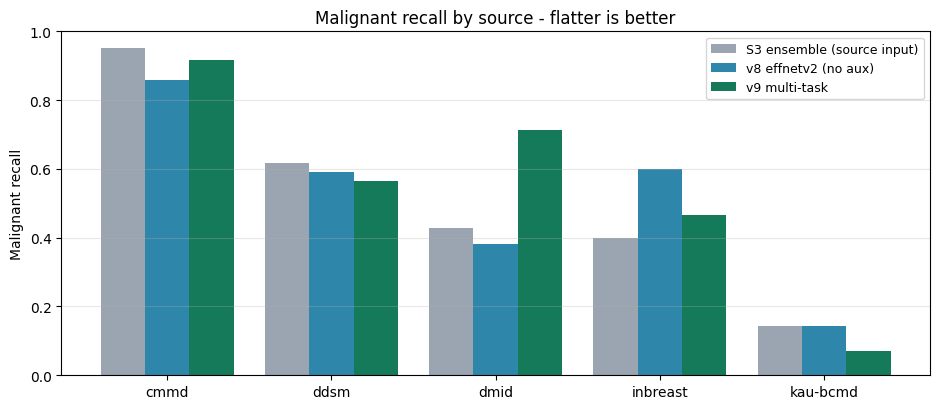

VERDICT
  worst-source malignant recall 0.1429 -> 0.0714  (-0.0715)
  Benign F1                     0.5851 -> 0.5754  (-0.0097)
  source spread                 0.7158 -> 0.8465  (+0.1307)
  -> the confounded labels entrenched the shortcut. Turn AUX_ABNORM off, keep density, rerun.


In [ ]:
# Sprint 3 ensemble WITH source (2 models + 4-view TTA + tuned coefficients)
OLD = {'aggregate': {'accuracy': 0.7373, 'macro_f1': 0.7415, 'benign_f1': 0.6340,
                     'mal_recall': 0.7811, 'mcc': 0.5908, 'macro_auc': 0.8918},
       'per_source_mal_recall': {'cmmd': 0.9514, 'ddsm': 0.6168, 'dmid': 0.4286,
                                 'inbreast': 0.4000, 'kau-bcmd': 0.1429}}

# v8 ResNet-101 no source - single model, no TTA, no tuning
V8_RESNET = {'aggregate': {'accuracy': 0.6930, 'macro_f1': 0.7033, 'benign_f1': 0.5942,
                           'mal_recall': 0.6728, 'mcc': 0.5286, 'macro_auc': 0.8696},
             'per_source_mal_recall': {'cmmd': 0.7660, 'ddsm': 0.5821, 'dmid': 0.4762,
                                       'inbreast': 0.4000, 'kau-bcmd': 0.4286}}

# v8 EfficientNetV2 no source - THE DIRECT BASELINE for this notebook
V8_EFFNET = {'aggregate': {'accuracy': 0.7097, 'macro_f1': 0.7152, 'benign_f1': 0.5851,
                           'mal_recall': 0.7229, 'mcc': 0.5508, 'macro_auc': 0.8675},
             'per_source_mal_recall': {'cmmd': 0.8587, 'ddsm': 0.5912, 'dmid': 0.3810,
                                       'inbreast': 0.6000, 'kau-bcmd': 0.1429}}

BASE = V8_EFFNET if ARCH == 'effnetv2' else V8_RESNET
BASE_NAME = f'v8 {ARCH} (no aux)'

def worst_and_spread(d):
    v = list(d.values()); return min(v), max(v) - min(v)

rows = []
for k in OLD['aggregate']:
    rows.append({'metric': k,
                 'S3 ensemble (source)': OLD['aggregate'][k],
                 BASE_NAME: BASE['aggregate'][k],
                 'v9 multi-task': tm[k],
                 'delta vs v8': round(tm[k] - BASE['aggregate'][k], 4)})
ow, osp = worst_and_spread(OLD['per_source_mal_recall'])
bw, bsp = worst_and_spread(BASE['per_source_mal_recall'])
nw  = per_src['mal_recall'].min()
nsp = per_src['mal_recall'].max() - nw
rows.append({'metric': 'WORST-SOURCE mal recall', 'S3 ensemble (source)': ow,
             BASE_NAME: bw, 'v9 multi-task': nw, 'delta vs v8': round(nw - bw, 4)})
rows.append({'metric': 'source spread (lower better)', 'S3 ensemble (source)': osp,
             BASE_NAME: bsp, 'v9 multi-task': nsp, 'delta vs v8': round(nsp - bsp, 4)})
display(pd.DataFrame(rows).set_index('metric').round(4))

x = np.arange(len(SOURCE_NAMES)); w = 0.27
plt.figure(figsize=(9.5, 4.2))
plt.bar(x-w, [OLD['per_source_mal_recall'].get(s, 0) for s in SOURCE_NAMES], w,
        label='S3 ensemble (source input)', color='#9AA5B1')
plt.bar(x,   [BASE['per_source_mal_recall'].get(s, 0) for s in SOURCE_NAMES], w,
        label=BASE_NAME, color='#2E86AB')
plt.bar(x+w, [per_src['mal_recall'].get(s, 0) for s in SOURCE_NAMES], w,
        label='v9 multi-task', color='#147A5A')
plt.xticks(x, SOURCE_NAMES); plt.ylabel('Malignant recall'); plt.ylim(0, 1)
plt.title('Malignant recall by source - flatter is better')
plt.legend(fontsize=9); plt.grid(alpha=.3, axis='y'); plt.tight_layout(); plt.show()

print('VERDICT')
d_worst  = nw - bw
d_benign = tm['benign_f1'] - BASE['aggregate']['benign_f1']
print(f'  worst-source malignant recall {bw:.4f} -> {nw:.4f}  ({d_worst:+.4f})')
print(f'  Benign F1                     {BASE["aggregate"]["benign_f1"]:.4f} -> {tm["benign_f1"]:.4f}  ({d_benign:+.4f})')
print(f'  source spread                 {bsp:.4f} -> {nsp:.4f}  ({nsp-bsp:+.4f})')
if d_worst > 0.05:
    print('  -> auxiliary supervision moved the failure mode. Keep it.')
elif d_worst < -0.02:
    print('  -> the confounded labels entrenched the shortcut. Turn AUX_ABNORM off, keep density, rerun.')
else:
    print('  -> no meaningful change in the failure mode. Judge on Benign F1, then try GROUP_DRO = True.')

## 12. Calibration and save

In [ ]:
def ece(probs, labels, n_bins=15):
    conf, pr = probs.max(1), probs.argmax(1)
    acc = (pr == labels).astype(np.float32)
    bins = np.linspace(0, 1, n_bins+1); e = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 0: e += m.mean()*abs(acc[m].mean()-conf[m].mean())
    return float(e)

sm2, sel_logits, sel_y, _ = evaluate(model, sel_loader, criterion, sel_src)
ece_before = ece(F.softmax(sel_logits, 1).numpy(), sel_y.numpy())

init_T = 1.0/LDAM_S if LOSS_TYPE == 'lmf' else 1.0
log_T = nn.Parameter(torch.log(torch.tensor([init_T], device=device, dtype=torch.float32)))
optT = torch.optim.LBFGS([log_T], lr=0.1, max_iter=500,
                         tolerance_grad=1e-9, tolerance_change=1e-11)
vl, vy = sel_logits.to(device), sel_y.to(device)
def closure():
    optT.zero_grad(); loss = F.cross_entropy(vl/torch.exp(log_T), vy); loss.backward(); return loss
optT.step(closure)
T = float(torch.exp(log_T).detach().cpu().item())
ece_after = ece(F.softmax(test_logits/T, 1).numpy(), yt)
print(f'Temperature T = {T:.5f}   ECE {ece_before:.4f} -> {ece_after:.4f}')

bundle = {'model_state_dict': model.state_dict(), 'temperature': T,
          'class_names': CLASS_NAMES, 'input_size': IMG_SIZE,
          'mean': NORM_MEAN, 'std': NORM_STD,
          'test_metrics': {k: v for k, v in tm.items() if k != 'per_source_mal_recall'},
          'per_source': per_src.reset_index().to_dict('records'),
          'ece_before': ece_before, 'ece_after': ece_after,
          'uses_source_embedding': USE_SOURCE, 'n_meta_embeddings': N_META,
          'aux_heads': {'density': AUX_DENSITY, 'abnormality': AUX_ABNORM, 'birads': AUX_BIRADS},
          'aux_weights': {'density': W_DENSITY, 'abnormality': W_ABNORM, 'birads': W_BIRADS},
          'balance_aux_by_source': BALANCE_AUX_BY_SOURCE,
          'group_dro': GROUP_DRO, 'dro_eta': DRO_ETA,
          'architecture': ('ResNet-101 + metadata' if ARCH == 'resnet101'
                           else 'EfficientNetV2-S + CBAM + metadata'),
          'loss': LOSS_TYPE, 'select_on': SELECT_ON,
          'split': 'frozen_split.json (train+old_val / selection / test)',
          'sprint': f'Sprint 4 / {TAG}'}
path = os.path.join(CHECKPT_DIR, f'final_{TAG}_bundle.pth')
torch.save(bundle, path)
per_src.to_csv(os.path.join(CHECKPT_DIR, f'per_source_{TAG}.csv'))
print('Saved:', path)

eval:   0%|          | 0/63 [00:00<?, ?it/s]

Temperature T = 2.06645   ECE 0.1143 -> 0.0152
Saved: /content/drive/MyDrive/momobench-dataset/checkpoints_v9_effnetv2_mt-da_ce/final_v9_effnetv2_mt-da_ce_bundle.pth


## How to read the result

**The auxiliary heads are a means, not an end.** Nobody cares whether this model predicts
BI-RADS well. The question is whether being forced to predict lesion morphology made the
backbone stop reading scanner signatures. Section 11 answers that in one number:
worst-source malignant recall against v8's 0.1429.

**Three outcomes and what each means.**

| Outcome | Reading | Next move |
|---|---|---|
| Worst-source recall rises above ~0.20 and Benign F1 holds | Auxiliary supervision is shaping the backbone. The mechanism works. | Keep it; tune `W_*`; ensemble with v8 |
| Nothing moves | The heads are too thin or too confounded to change the trunk | `GROUP_DRO = True` — attack the objective instead of the representation |
| Worst-source recall *falls* | The confounded labels taught provenance, exactly as section 3a warned | `AUX_ABNORM = False`, keep density only, rerun |

**Check section 10 before believing any of it.** If a head sits at majority-class accuracy it
never learned its task, so it cannot have shaped the backbone, and any change you see is run
variance rather than the intervention. v7 showed roughly 3 points of run-to-run movement on
malignant recall between identical configurations — treat anything smaller than that as noise.

## Runs to queue

1. `AUX_DENSITY=True, AUX_ABNORM=True, GROUP_DRO=False` — as configured. The main experiment.
2. `AUX_DENSITY=True, AUX_ABNORM=False` — density only. Cleanest of the auxiliary labels,
   covers four sources including KAU-BCMD, least confounded.
3. `AUX_*=False, GROUP_DRO=True` — worst-group optimisation on its own, no auxiliary heads.
   The control that says whether the gain came from the labels or from the objective.

Three runs at roughly 2.5 hours each. Run 1 and run 3 are the two that matter; run 2 only if
run 1 moves the number and you need to know which head did it.